# Modélisation 

### 1. Analyse en Composantes Principales et préparation de la modélisation

Nous réalisons une Analyse en Composantes Principales mutualisée afin de synthétiser l'information et comparer les années entre elles.



In [14]:
# Importation des librairies nécessaires 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import importlib.util
from pathlib import Path
import seaborn as sns
#from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [15]:
# ACP mutualisée 

def compute_pca_all_years(df, pca_cols, n_components=3):
    """
    On regroupe les données de toutes les années pour calculer les composantes principales.
    Cela permet de pouvoir comparer les composantes principales d'une année à l'autre.
    Si l'on avait calculé les composantes principales pour chaque année,
    on aurait obtenu des composantes principales différentes pour chaque année => difficile à interpréter.
    """
    df_result = df.copy()
    
    # Préparation des données regroupées (toutes les années combinées)
    # Remplissage des valeurs manquantes par la moyenne spécifique à chaque année avant le regroupement
    df_filled = df.copy()
    for col in pca_cols:
        df_filled[col] = df_filled.groupby('Year')[col].transform(lambda x: x.fillna(x.mean()))
    
    # Extraction de toutes les données disponibles pour l'ajustement de l'ACP
    X_pooled = df_filled[pca_cols].dropna().values
    
    # Standardisation des données regroupées
    scaler = StandardScaler()
    X_pooled_scaled = scaler.fit_transform(X_pooled)

    # Graphique du coude (Scree Plot)
    pca_full = PCA()
    pca_full.fit(X_pooled_scaled)
    exp_var_ratio = pca_full.explained_variance_ratio_
    cum_var_ratio = np.cumsum(exp_var_ratio)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.7, 
            color='steelblue', label='Variance Individuelle')
    plt.step(range(1, len(exp_var_ratio) + 1), cum_var_ratio, where='mid', 
             color='red', linestyle='--', label='Variance Cumulative')
    plt.axhline(y=1/len(pca_cols), color='green', linestyle=':', 
                label='Seuil de Kaiser')
    plt.title("Graphique du Coude (Scree Plot) - Sélection des Composantes", fontsize=12)
    plt.xlabel('Composante Principale')
    plt.ylabel('Ratio de Variance Expliquée')
    plt.legend(loc='best')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Ajustement de l'ACP sur les données regroupées
    pca = PCA(n_components=n_components)
    pca.fit(X_pooled_scaled)
    
    print(f"\nACP variance expliquée (premières {n_components} composantes):")
    for i in range(n_components):
        print(f"  CP{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")
    print(f"  Cumulée: {pca.explained_variance_ratio_[:n_components].sum():.4f} ({pca.explained_variance_ratio_[:n_components].sum()*100:.2f}%)")
    
    # Visualisation des coefficients (loadings) et des contributions
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'CP{i+1}' for i in range(n_components)],
        index=pca_cols
    )
    
    # Barplot des loadings par composante
    plt.figure(figsize=(12, 8))
    for i in range(n_components):
        plt.subplot(n_components, 1, i + 1)
        sns.barplot(
            x=loadings.index,
            y=loadings.iloc[:, i],
            palette='viridis'
        )
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Poids')
        plt.title(f'Loadings de CP{i+1}')
    plt.tight_layout()
    plt.savefig('3_Exploration/Fig18_pca_loadings.png', dpi=300, bbox_inches='tight')
    
    # Barplot des contributions (variance expliquée)
    plt.figure(figsize=(6, 4))
    sns.barplot(
        x=[f'CP{i+1}' for i in range(n_components)],
        y=pca.explained_variance_ratio_[:n_components],
        palette='magma'
    )
    plt.ylabel('Part de variance')
    plt.title('Variance expliquée par composante')
    plt.tight_layout()
    plt.savefig('3_Exploration/Fig18_pca_variance.png', dpi=300, bbox_inches='tight')
    
    # Application de l'ACP à chaque année en utilisant la même transformation
    for year in df['Year'].unique():
        df_year = df_filled[df_filled['Year'] == year].copy()
        
        if len(df_year) == 0:
            continue
        
        # Extraction des caractéristiques pour cette année
        X_year = df_year[pca_cols].values
        
        # Standardisation en utilisant le même scaler ajusté sur les données regroupées
        X_year_scaled = scaler.transform(X_year)
        
        # Application de la transformation ACP
        principal_components = pca.transform(X_year_scaled)
        
        # Stockage des résultats
        for i in range(n_components):
            df_result.loc[df_result['Year'] == year, f'PC{i+1}'] = principal_components[:, i]
    
    return df_result

Le code suivant transforme des données brutes en un jeu de données de panel structuré en synthétisant les indicateurs de santé et d'économie par les trois composantes principales (PC1, PC2, PC3) calculées précédemment pour capturer l'essentiel de la variance.

Il génère une variable cible de mortalité infantile assortie d'une variable de mortalité infantile décalée (t−1) afin de permettre une analyse de l'évolution temporelle par pays. 

Enfin, il nettoie le tableau en attribuant des identifiants uniques et en supprimant les valeurs manquantes pour rendre les données prêtes à la modélisation.

Computing PCA components for all years...


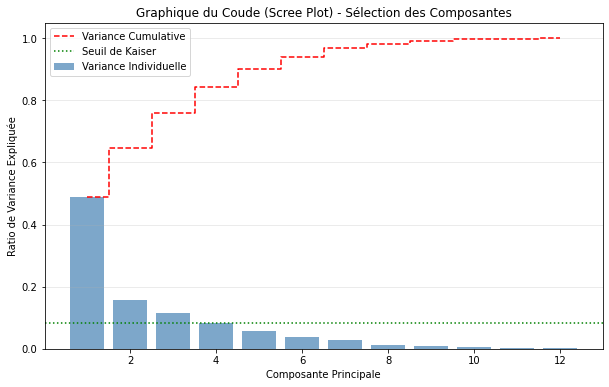


ACP variance expliquée (premières 3 composantes):
  CP1: 0.4886 (48.86%)
  CP2: 0.1573 (15.73%)
  CP3: 0.1141 (11.41%)
  Cumulée: 0.7600 (76.00%)

 336 observations
Pays: 24
Années: 2011 à 2024

Données de panel générées (avec lags): healthcare_data_25countries/MASTER_DATASET_PANEL_LAGS.csv


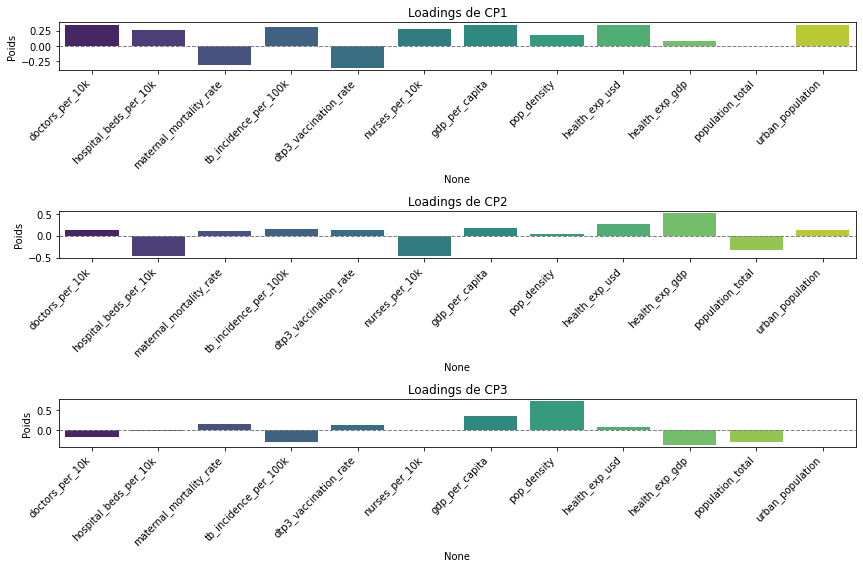

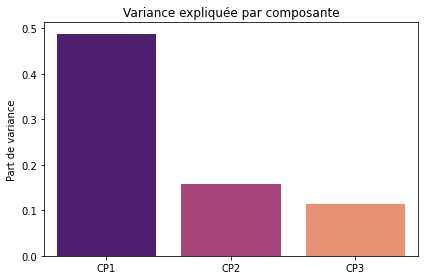

In [16]:
def prepare_panel_data_with_lags(file_path):
    """
    Crée un dataframe comprenant :
    - Country_ID (Identifiant du pays)
    - Year (Année)
    - PC1, PC2, PC3 (Composantes principales)
    - Lag_Mortality (Taux de mortalité infantile à t-1)
    - Target_Mortality (Taux de mortalité infantile à t)
    """
    df = pd.read_csv(file_path)
    
    # --- Variables pour l'ACP (12 variables excluant le taux de mortalité infantile) ---
    pca_cols = [
        'doctors_per_10k', 'hospital_beds_per_10k', 
        'maternal_mortality_rate', 'tb_incidence_per_100k', 'dtp3_vaccination_rate', 
        'nurses_per_10k', 'gdp_per_capita', 'pop_density', 'health_exp_usd', 
        'health_exp_gdp', 'population_total', 'urban_population'
    ]
    
    # Calcul de l'ACP pour toutes les années
    print("Computing PCA components for all years...")
    df = compute_pca_all_years(df, pca_cols, n_components=3)
    
    # Création de la correspondance pour l'identifiant pays (Country_ID)
    unique_countries = df['Country'].unique()
    country_id_map = {country: idx + 1 for idx, country in enumerate(sorted(unique_countries))}
    df['Country_ID'] = df['Country'].map(country_id_map)
    
    # Tri par pays et par année pour assurer un décalage correct
    df = df.sort_values(['Country', 'Year']).reset_index(drop=True)
    
    # Création de la mortalité décalée (t-1) et de la mortalité cible (t)
    df['Lag_Mortality'] = df.groupby('Country')['infant_mortality_rate'].shift(1)
    df['Target_Mortality'] = df['infant_mortality_rate']
    
    # Sélection uniquement des colonnes requises
    panel_df = df[['Country_ID', 'Year', 'PC1', 'PC2', 'PC3', 'Lag_Mortality', 'Target_Mortality']].copy()
    
    # Suppression des lignes où Lag_Mortality est NaN (première année pour chaque pays)
    panel_df = panel_df.dropna(subset=['PC1', 'PC2', 'PC3', 'Lag_Mortality', 'Target_Mortality'])
    
    print(f"\n {len(panel_df)} observations")
    print(f"Pays: {len(panel_df['Country_ID'].unique())}")
    print(f"Années: {panel_df['Year'].min()} à {panel_df['Year'].max()}")
    
    return panel_df, country_id_map


if __name__ == "__main__":
    # Chemin vers le fichier de données d’entrée
    file_path_clean = 'healthcare_data_25countries/MASTER_DATASET_CLEAN.csv'
    
    # Préparation des données de panel avec variables retardées
    panel_df, country_map = prepare_panel_data_with_lags(file_path_clean)
    
    # Save the prepared panel dataframe
    output_path = 'healthcare_data_25countries/MASTER_DATASET_PANEL_LAGS.csv'
    panel_df.to_csv(output_path, index=False)
    print(f"\nDonnées de panel générées (avec lags): {output_path}")

Dans une ACP sur données standardisées, on retient généralement les composantes dont la valeur propre est supérieure à 1. En termes de ratio de variance, cela revient à tracer une ligne à $1 / \text{nombre de variables}$. Dans le graphique du coude, on voit bien que seules les 3 premières composantes sont au-dessus de ce seuil. Nous retenous ainsi les 3 premières composantes principales pour la suite de notre analyse.

Nos trois composantes principales permettent d'expliquer 76% de la variance totale de note vatriable d'intérêt, le taux de mortalité infantile. Les composantes ont été sélectionnées avec le critère de Kaiser.
La première composante CP1 représente la richesse du pays. La seconde CP2 représente le contraste entre les dépenses en santé et le volume de celui-ci. la troisième, CP3 représente la densité de population.

### 2. Modèle A : Régression linéaire à effets fixes

Nous utilisons un modèle de régression linéaire à effets fixes afin d’analyser la relation entre la mortalité infantile cible et plusieurs variables explicatives, dont l’année et les trois composantes principales. 

Les effets fixes pays permettent de contrôler l’hétérogénéité structurelle des pays. 

Les performances du modèle sont évaluées à l’aide du R², du RMSE et d’analyses graphiques des prédictions et des résidus.


Modèle A : Régression linéaire à effets fixes
Formule: Target_Mortality ~ Year + PC1 + PC2 + PC3 + Effets fixes pays

R² (Coefficient de détermination): 0.9871
RMSE (Erreur quadratique moyenne): 1.9444

Coefficients principaux :
      Coefficient  Std Error  t-statistic       p-value Signif.
Year    -0.470962   0.000671  -701.864040  0.000000e+00     ***
PC1     -0.687764   0.322396    -2.133294  3.369078e-02       *
PC2      2.149871   0.259784     8.275601  3.996803e-15     ***
PC3      6.322750   0.650376     9.721679  0.000000e+00     ***

Intercept: 1004.3027

Nombre d'effets fixes pays: 23

TEST F POUR LA SIGNIFICATIVITÉ CONJOINTE DES COMPOSANTES PRINCIPALES

H0: PC1 = PC2 = PC3 = 0 (les PCs n'ont pas d'effet conjoint)
H1: Au moins une PC a un effet significatif

Statistique F: 47.3236
Degrés de liberté: (3, 308)
P-value: 1.1102e-16

Conclusion: *** Les composantes principales sont conjointement TRÈS SIGNIFICATIVES

Légende: *** p<0.001, ** p<0.01, * p<0.05

fig17 done


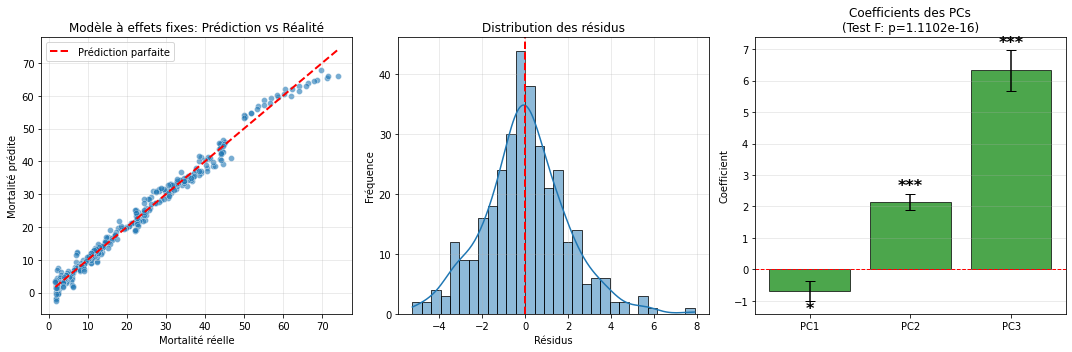

In [ ]:
def run_fixed_effects_regression(panel_df):
    """
    Modèle A : Régression linéaire à effets fixes
    Formule : Target_Mortality ~ Year + PC1 + PC2 + PC3 + Effets fixes pays
    Objectif : évaluer dans quelle mesure les composantes principales
               expliquent la mortalité cible
    """
    from scipy import stats
    
    # Préparation des variables explicatives
    X_features = panel_df[['Year', 'PC1', 'PC2', 'PC3']].copy()

    # Ajout des effets fixes pays (variables muettes par pays)
    country_dummies = pd.get_dummies(panel_df['Country_ID'], prefix='Country', drop_first=True)

    # Combinaison des variables explicatives et des effets fixes
    X = pd.concat([X_features, country_dummies], axis=1)
    y = panel_df['Target_Mortality']

    # Estimation du modèle COMPLET
    model = LinearRegression()
    model.fit(X, y)

    # Prédictions du modèle
    y_pred = model.predict(X)

    # Indicateurs de performance
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Calcul de la variance résiduelle pour le modèle complet
    n = len(y)
    k = X.shape[1]  # nombre total de variables
    residuals = y - y_pred
    rss_full = np.sum(residuals**2)  # Somme des carrés des résidus
    mse_full = rss_full / (n - k - 1)  # Variance résiduelle
    
    #   F TEST 
    # Modèle RESTREINT sans PC1, PC2, PC3
    X_features_restricted = panel_df[['Year']].copy()
    X_restricted = pd.concat([X_features_restricted, country_dummies], axis=1)
    
    model_restricted = LinearRegression()
    model_restricted.fit(X_restricted, y)
    y_pred_restricted = model_restricted.predict(X_restricted)
    
    # Calcul des statistiques pour le test F
    rss_restricted = np.sum((y - y_pred_restricted)**2)
    
    # Nombre de restrictions (nombre de PCs testées)
    q = 3  # PC1, PC2, PC3
    
    # Statistique F
    f_statistic = ((rss_restricted - rss_full) / q) / mse_full
    
    # P-value associée
    p_value = 1 - stats.f.cdf(f_statistic, q, n - k - 1)
    
    # Calcul des erreurs-types et t-stats pour les coefficients individuels
    # Conversion explicite en float64
    X_array = X.astype(np.float64).values
    y_array = y.astype(np.float64).values
    
    # Matrice de variance-covariance des coefficients
    try:
        XtX_inv = np.linalg.inv(X_array.T @ X_array)
        var_covar = mse_full * XtX_inv
        std_errors = np.sqrt(np.diag(var_covar))
    except np.linalg.LinAlgError:
        # Si la matrice est singulière, utiliser la pseudo-inverse
        XtX_pinv = np.linalg.pinv(X_array.T @ X_array)
        var_covar = mse_full * XtX_pinv
        std_errors = np.sqrt(np.diag(var_covar))
    
    # T-statistiques et p-values pour chaque coefficient
    t_stats = model.coef_ / std_errors
    p_values_individual = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - k - 1))
    
    #  AFFICHAGE RÉSULTATS 
    print("\nModèle A : Régression linéaire à effets fixes")
    print(f"Formule: Target_Mortality ~ Year + PC1 + PC2 + PC3 + Effets fixes pays")
    print(f"\nR² (Coefficient de détermination): {r2:.4f}")
    print(f"RMSE (Erreur quadratique moyenne): {rmse:.4f}")

    # Coefficients des variables principales avec statistiques
    feature_names = ['Year', 'PC1', 'PC2', 'PC3']
    coeff_df = pd.DataFrame({
        'Coefficient': model.coef_[:len(feature_names)],
        'Std Error': std_errors[:len(feature_names)],
        't-statistic': t_stats[:len(feature_names)],
        'p-value': p_values_individual[:len(feature_names)]
    }, index=feature_names)
    
    # Ajout des étoiles de significativité
    def add_significance_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return ''
    
    coeff_df['Signif.'] = coeff_df['p-value'].apply(add_significance_stars)

    print("\nCoefficients principaux :")
    print(coeff_df.to_string())
    print(f"\nIntercept: {model.intercept_:.4f}")
    print(f"\nNombre d'effets fixes pays: {len(country_dummies.columns)}")
    
    #   F TEST  
    print("TEST F POUR LA SIGNIFICATIVITÉ CONJOINTE DES COMPOSANTES PRINCIPALES")
    print(f"\nH0: PC1 = PC2 = PC3 = 0 (les PCs n'ont pas d'effet conjoint)")
    print(f"H1: Au moins une PC a un effet significatif")
    print(f"\nStatistique F: {f_statistic:.4f}")
    print(f"Degrés de liberté: ({q}, {n - k - 1})")
    print(f"P-value: {p_value:.4e}")
    
    if p_value < 0.001:
        conclusion = "*** Les composantes principales sont conjointement TRÈS SIGNIFICATIVES"
    elif p_value < 0.01:
        conclusion = "** Les composantes principales sont conjointement SIGNIFICATIVES"
    elif p_value < 0.05:
        conclusion = "* Les composantes principales sont conjointement significatives"
    else:
        conclusion = "Les composantes principales ne sont PAS conjointement significatives"
    
    print(f"\nConclusion: {conclusion}")
    print("="*70)
    
    # Légende des seuils de significativité
    print("\nLégende: *** p<0.001, ** p<0.01, * p<0.05")

    # Visualisation
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.scatterplot(x=y, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité réelle')
    plt.ylabel('Mortalité prédite')
    plt.title('Modèle à effets fixes: Prédiction vs Réalité')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    residuals = y - y_pred
    sns.histplot(residuals, kde=True, bins=30)
    plt.xlabel('Résidus')
    plt.ylabel('Fréquence')
    plt.title('Distribution des résidus')
    plt.axvline(0, color='r', linestyle='--', linewidth=2)
    plt.grid(True, alpha=0.3)
    
    # Graphique des coefficients des PCs avec barres d'erreur
    plt.subplot(1, 3, 3)
    pc_names = ['PC1', 'PC2', 'PC3']
    pc_indices = [feature_names.index(pc) for pc in pc_names]
    pc_coefs = coeff_df.loc[pc_names, 'Coefficient'].values
    pc_errors = coeff_df.loc[pc_names, 'Std Error'].values
    pc_pvalues = coeff_df.loc[pc_names, 'p-value'].values
    
    colors = ['green' if p < 0.05 else 'gray' for p in pc_pvalues]
    plt.bar(range(len(pc_names)), pc_coefs, yerr=pc_errors, 
            capsize=5, alpha=0.7, color=colors, edgecolor='black')
    plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
    plt.xticks(range(len(pc_names)), pc_names)
    plt.ylabel('Coefficient')
    plt.title(f'Coefficients des PCs\n(Test F: p={p_value:.4e})')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Ajouter les étoiles de significativité
    for i, (coef, pval) in enumerate(zip(pc_coefs, pc_pvalues)):
        stars = add_significance_stars(pval)
        if stars:
            offset = pc_errors[i] if coef > 0 else -pc_errors[i]
            plt.text(i, coef + offset, stars, ha='center', 
                    va='bottom' if coef > 0 else 'top', 
                    fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig('3_Exploration/Fig17_fixed_effects_regression.png', dpi=300, bbox_inches='tight')
    print("\nfig17 done")
    
    # Retourner aussi les résultats du test F
    test_results = {
        'f_statistic': f_statistic,
        'p_value': p_value,
        'df_numerator': q,
        'df_denominator': n - k - 1
    }

    return model, coeff_df, test_results

if __name__ == "__main__":
    # Estimation du modèle de régression à effets fixes
    model_a, coefficients_a, f_test_results_a = run_fixed_effects_regression(panel_df)


Nous constatons que le modèle à effets fixes prédit assez bien la mortalité infantile. 

D'une part, le graphique de comparant les valeurs observées et prédites de la mortalité infantile montre une forte concentration des observations le long de la droite de prédiction, traduisant une bonne efficacité du modèle après la prise en compte des effets fixes par pays.

D'autre part, la distribution des résidus est globalement centrée autour de zéro et proche d’une distribution normale. La normalité des résidus nous rassure sur la linéarité des liens entre la mortalité infantile et nos variables explicatives. 

Globalement, ces résultats montrent que les composantes principales et l’évolution dans le temps expliquent bien les variations de la mortalité au sein de chaque pays, une fois les différences structurelles entre pays prises en compte.

### 3. Modèle B : Régression à effets fixes avec prise en compte de la mortalité infantile en t-1

Le code suivant estime un modèle de régression linéaire à effets fixes intégrant la mortalité retardée afin de prendre en compte la persistance temporelle de la mortalité infantile au sein de chaque pays. 

Comme pour le modèle A, contrôler les effets fixes pays, permet d'isoler les variations intra-pays et d'évaluer l’apport explicatif de la mortalité passée, de la tendance temporelle et des composantes principales sur la mortalité actuelle.

Le premier modèle nous garanti que nos variables sont pertinentes pour estimer le taux de mortalité infantile. Ce modèle là, est plus réaliste dans la prédiction : on connait souvant les taux de mortalité antérieurs et ceux-ci semblent pertinents afin de prédire le prochain taux de mortalité. 


Modèle B: Régression à effets fixes avec prise en compte de la mortalité infantile en t-1
Formule : Target_Mortality ~ Lag_Mortality + Year + PC1 + PC2 + PC3 + Effets fixes pays

R² (Coefficient de détermination): 0.9998
RMSE (Erreur quadratique moyenne): 0.2641

Coefficients principaux (avec lag) :
               Coefficient  Std Error  t-statistic   p-value Signif.
Year              0.019479   0.000171   114.152706  0.000000     ***
PC1              -0.122437   0.050775    -2.411377  0.016479       *
PC2               0.029763   0.035922     0.828548  0.408004        
PC3               0.175191   0.104085     1.683165  0.093360        
Lag_Mortality     0.924725   0.005942   155.637272  0.000000     ***

Intercept: -36.9434

Nombre d'effets fixes pays: 23
TEST F POUR LA SIGNIFICATIVITÉ CONJOINTE DES COMPOSANTES PRINCIPALES

H0: PC1 = PC2 = PC3 = 0 (les PCs n'ont pas d'effet conjoint)
H1: Au moins une PC a un effet significatif

Statistique F: 2.8569
Degrés de liberté: (3, 307)
P-val

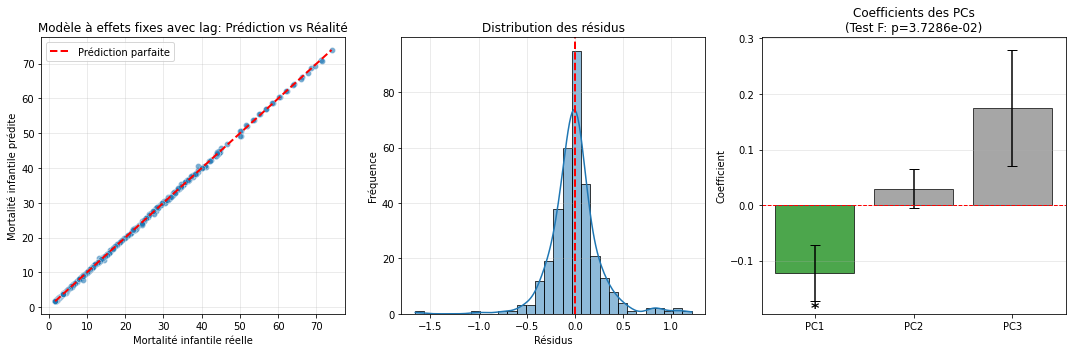

In [21]:
def run_fixed_effects_regression_with_lag(panel_df):
    """
    Modèle B : Régression à effets fixes avec prise en compte de la mortalité infantile en t-1
    Formule : Target_Mortality ~ Lag_Mortality + Year + PC1 + PC2 + PC3 + Effets fixes pays
    Objectif : prédire le taux de mortalité à partir de la mortalité passée
    et des composantes principales
    """
    from scipy import stats
    
    # Sélection des variables explicatives
    feature_cols = ['Year', 'PC1', 'PC2', 'PC3', 'Lag_Mortality']
    X_features = panel_df[feature_cols].copy()
    
    # Ajout des effets fixes pays (variables muettes)
    country_dummies = pd.get_dummies(panel_df['Country_ID'], prefix='Country', drop_first=True)
    
    # Combinaison des variables explicatives et des effets fixes
    X = pd.concat([X_features, country_dummies], axis=1)
    y = panel_df['Target_Mortality']

    # Estimation du modèle COMPLET
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Calcul de la variance résiduelle pour le modèle complet
    n = len(y)
    k = X.shape[1]  # nombre total de variables
    residuals = y - y_pred
    rss_full = np.sum(residuals**2)  # Somme des carrés des résidus
    mse_full = rss_full / (n - k - 1)  # Variance résiduelle
    
    #F test POUR LES COMPOSANTES PRINCIPALES
    # Modèle RESTREINT sans PC1, PC2, PC3
    feature_cols_restricted = ['Year', 'Lag_Mortality']
    X_features_restricted = panel_df[feature_cols_restricted].copy()
    X_restricted = pd.concat([X_features_restricted, country_dummies], axis=1)
    
    model_restricted = LinearRegression()
    model_restricted.fit(X_restricted, y)
    y_pred_restricted = model_restricted.predict(X_restricted)
    
    # Calcul des statistiques pour le test F
    rss_restricted = np.sum((y - y_pred_restricted)**2)
    
    # Nombre de restrictions (nombre de PCs testées)
    q = 3  # PC1, PC2, PC3
    
    # Statistique F
    f_statistic = ((rss_restricted - rss_full) / q) / mse_full
    
    # P-value associée
    p_value = 1 - stats.f.cdf(f_statistic, q, n - k - 1)
    
    # Calcul des erreurs-types et t-stats pour les coefficients individuels
    # Conversion explicite en float64
    X_array = X.astype(np.float64).values
    y_array = y.astype(np.float64).values
    
    # Matrice de variance-covariance des coefficients
    try:
        XtX_inv = np.linalg.inv(X_array.T @ X_array)
        var_covar = mse_full * XtX_inv
        std_errors = np.sqrt(np.diag(var_covar))
    except np.linalg.LinAlgError:
        # Si la matrice est singulière, utiliser la pseudo-inverse
        XtX_pinv = np.linalg.pinv(X_array.T @ X_array)
        var_covar = mse_full * XtX_pinv
        std_errors = np.sqrt(np.diag(var_covar))
    
    # T-statistiques et p-values pour chaque coefficient
    t_stats = model.coef_ / std_errors
    p_values_individual = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - k - 1))
    
    # ========== AFFICHAGE DES RÉSULTATS ==========
    print("\nModèle B: Régression à effets fixes avec prise en compte de la mortalité infantile en t-1")
    print("Formule : Target_Mortality ~ Lag_Mortality + Year + PC1 + PC2 + PC3 + Effets fixes pays")
    print(f"\nR² (Coefficient de détermination): {r2:.4f}")
    print(f"RMSE (Erreur quadratique moyenne): {rmse:.4f}")
    
    # Coefficients des variables principales avec statistiques
    coeff_df = pd.DataFrame({
        'Coefficient': model.coef_[:len(feature_cols)],
        'Std Error': std_errors[:len(feature_cols)],
        't-statistic': t_stats[:len(feature_cols)],
        'p-value': p_values_individual[:len(feature_cols)]
    }, index=feature_cols)
    
    # Ajout des étoiles de significativité
    def add_significance_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return ''
    
    coeff_df['Signif.'] = coeff_df['p-value'].apply(add_significance_stars)
    
    print("\nCoefficients principaux (avec lag) :")
    print(coeff_df.to_string())
    print(f"\nIntercept: {model.intercept_:.4f}")
    print(f"\nNombre d'effets fixes pays: {len(country_dummies.columns)}")
    
    # F test  
    print("TEST F POUR LA SIGNIFICATIVITÉ CONJOINTE DES COMPOSANTES PRINCIPALES")
    print(f"\nH0: PC1 = PC2 = PC3 = 0 (les PCs n'ont pas d'effet conjoint)")
    print(f"H1: Au moins une PC a un effet significatif")
    print(f"\nStatistique F: {f_statistic:.4f}")
    print(f"Degrés de liberté: ({q}, {n - k - 1})")
    print(f"P-value: {p_value:.4e}")
    
    if p_value < 0.001:
        conclusion = "*** Les composantes principales sont conjointement TRÈS SIGNIFICATIVES"
    elif p_value < 0.01:
        conclusion = "** Les composantes principales sont conjointement SIGNIFICATIVES"
    elif p_value < 0.05:
        conclusion = "* Les composantes principales sont conjointement significatives"
    else:
        conclusion = "Les composantes principales ne sont PAS conjointement significatives"
    
    print(f"\nConclusion: {conclusion}")
    print("="*70)
    
    # Légende des seuils de significativité
    print("\nLégende: *** p<0.001, ** p<0.01, * p<0.05")
    
    # Visualisation
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=y, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité infantile réelle')
    plt.ylabel('Mortalité infantile prédite')
    plt.title('Modèle à effets fixes avec lag: Prédiction vs Réalité')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    residuals = y - y_pred
    sns.histplot(residuals, kde=True, bins=30)
    plt.xlabel('Résidus')
    plt.ylabel('Fréquence')
    plt.title('Distribution des résidus')
    plt.axvline(0, color='r', linestyle='--', linewidth=2)
    plt.grid(True, alpha=0.3)
    
    # Graphique des coefficients des PCs avec barres d'erreur
    plt.subplot(1, 3, 3)
    pc_names = ['PC1', 'PC2', 'PC3']
    pc_indices = [feature_cols.index(pc) for pc in pc_names]
    pc_coefs = coeff_df.loc[pc_names, 'Coefficient'].values
    pc_errors = coeff_df.loc[pc_names, 'Std Error'].values
    pc_pvalues = coeff_df.loc[pc_names, 'p-value'].values
    
    colors = ['green' if p < 0.05 else 'gray' for p in pc_pvalues]
    plt.bar(range(len(pc_names)), pc_coefs, yerr=pc_errors, 
            capsize=5, alpha=0.7, color=colors, edgecolor='black')
    plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
    plt.xticks(range(len(pc_names)), pc_names)
    plt.ylabel('Coefficient')
    plt.title(f'Coefficients des PCs\n(Test F: p={p_value:.4e})')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Ajouter les étoiles de significativité
    for i, (coef, pval) in enumerate(zip(pc_coefs, pc_pvalues)):
        stars = add_significance_stars(pval)
        if stars:
            offset = pc_errors[i] if coef > 0 else -pc_errors[i]
            plt.text(i, coef + offset, stars, ha='center', 
                    va='bottom' if coef > 0 else 'top', 
                    fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('3_Exploration/Fig19_fixed_effects_regression_with_lag.png', dpi=300, bbox_inches='tight')
    print("\nfig19 done (avec lag)")
    
    # Retourner aussi les résultats du test F
    test_results = {
        'f_statistic': f_statistic,
        'p_value': p_value,
        'df_numerator': q,
        'df_denominator': n - k - 1
    }
    
    return model, coeff_df, test_results

# Estimation du modèle à effets fixes avec variable retardée
model_b, coefficients_b, f_test_results = run_fixed_effects_regression_with_lag(panel_df)


Nous constatons que, par rapport au modèle A, l’ajout de la mortalité infantile de l'année t-1 améliore nettement la qualité des prédictions.

Le modèle B reproduit presque parfaitement les niveaux observés de mortalité, ce qui montre que la mortalité passée joue un rôle déterminant dans l’évolution de la mortalité actuelle.

Les erreurs de prédiction sont plus faibles et mieux centrées autour de zéro que dans le modèle A, indiquant une meilleure prise en compte de la dynamique temporelle au sein des pays.

#### Conclusion des modèles A et B 

Finalement, les modèles de régression à effets fixes affichent une excellente capacité de prédiction, en particulier lorsque la mortalité infantile de l'année précédenten est incluse.

Cependant, ces performances reposent en grande partie sur des relations linéaires et sur une forte dépendance aux tendances passées. Nous constatons que l'ajout du taux de moratalité passé a pour conséquence de diminuer fortement les coefficients des variables. Se pose alors la question de leur significance statistique.
Aussi, le poids très élevé du taux de mortalité passé rend le modèle incapable de prédire des ruptures de tendance et prédira toujours une mortalité relativement proche de la dernière période.

Afin de pallier cette limite nous allons tester l'utilisation d'un modèle d’apprentissage automatique tel que XGBoost pour capturer des relations plus complexes et améliorer la capacité de généralisation.

### 4. Modèle XGBoost et comparaison avec le modèle de régression linéaire

L'objectif de cette partie est de d'appliquer un modèle d'apprentissage XGBoost et de comparer son efficacité avec les modèles de régression linéaire à effets fixes des parties précédentes.

Les codes suivants préparent les données pour appliquer le modèle XGboost. Le modèle est entrainé sur les années 2010 à 2023 et testé sur l'année 2024.

**Important**: Nous réutilisons le `panel_df` déjà calculé (ACP déjà effectuée dans la Cellule 4) et la fonction de régression linéaire déjà définie (Cellule 10) pour éviter de recalculer l'ACP et de dupliquer le code de régression. 

In [ ]:
def build_features_with_fe(panel_df):
    """
    Construire la matrice de caractéristiques avec :
    - Année
    - PC1, PC2, PC3
    - Mortalité retardée
    - Effets fixes par pays (one-hot, drop_first pour éviter la colinéarité)
    """
    feature_cols = ['Year', 'PC1', 'PC2', 'PC3', 'Lag_Mortality']
    X_num = panel_df[feature_cols].copy()
    country_dummies = pd.get_dummies(panel_df['Country_ID'], prefix='Country', drop_first=True)
    X = pd.concat([X_num, country_dummies], axis=1)
    y = panel_df['Target_Mortality']
    return X, y


def walk_forward_split(panel_df, train_start_year=2010, train_end_year=2023, test_start_year=2024):
    """
    Split walk forward:
    - Train: years >= train_start_year and <= train_end_year
    - Test : years >= test_start_year
    """
    train_mask = (panel_df['Year'] >= train_start_year) & (panel_df['Year'] <= train_end_year)
    test_mask = panel_df['Year'] >= test_start_year

    if not train_mask.any() or not test_mask.any():
        raise ValueError("La séparation train/test est vide. Vérifiez les années dans le dataset.")

    return train_mask, test_mask

Le code suivant évalue le modèle XGBoost et le modèle de régression linéaire à effets fixes (modèle B)


Modèle B: Régression à effets fixes avec prise en compte de la mortalité infantile en t-1
Formule : Target_Mortality ~ Lag_Mortality + Year + PC1 + PC2 + PC3 + Effets fixes pays

R² (Coefficient de détermination): 0.9998
RMSE (Erreur quadratique moyenne): 0.2387

Coefficients principaux (avec lag) :
               Coefficient
Year              0.017621
PC1              -0.102496
PC2               0.029237
PC3               0.196281
Lag_Mortality     0.938460

Intercept: -34.0603

Nombre d'effets fixes pays: 23

fig19 done (avec lag)

Évaluation walk-forward (Train: 2010-2023, Test: 2024)

=== Performance sur les données d'entraînement ===
Régression linéaire - RMSE: 0.2387, R²: 0.9998
XGBoost            - RMSE: 0.0790, R²: 1.0000

=== Performance sur les données de test ===
Régression linéaire - RMSE: 0.5468, R²: 0.9986
XGBoost            - RMSE: 1.2878, R²: 0.9922


{'rmse_linear_fe_lag_train': 0.23866991059650122,
 'rmse_linear_fe_lag_test': 0.5468214213678354,
 'rmse_xgboost_train': 0.07897170125135716,
 'rmse_xgboost_test': 1.2878162336842085,
 'r2_linear_fe_lag_train': 0.9998096182619937,
 'r2_linear_fe_lag_test': 0.9985901741914939,
 'r2_xgboost_train': 0.9999791563902111,
 'r2_xgboost_test': 0.9921804419444281,
 'y_train': array([73.94238697, 71.19437086, 68.62567142, 66.27921923, 64.14319215,
        62.18389061, 60.3522546 , 58.58494828, 56.87289928, 55.22117379,
        53.56895438, 51.89493142, 50.29011368, 35.39907857, 34.02891293,
        32.67653538, 31.3206238 , 29.95046333, 28.61715398, 27.37563752,
        26.28826106, 25.41093922, 24.81694514, 24.4621173 , 24.33142943,
        24.33919305, 15.2932005 , 14.77209165, 14.34089064, 13.99236563,
        13.70111979, 14.5599418 , 13.25630086, 13.07756374, 12.92720561,
        12.79569778, 12.68045333, 12.56512951, 12.43759129,  7.35650224,
         7.2135529 ,  7.07834785,  6.95155857, 

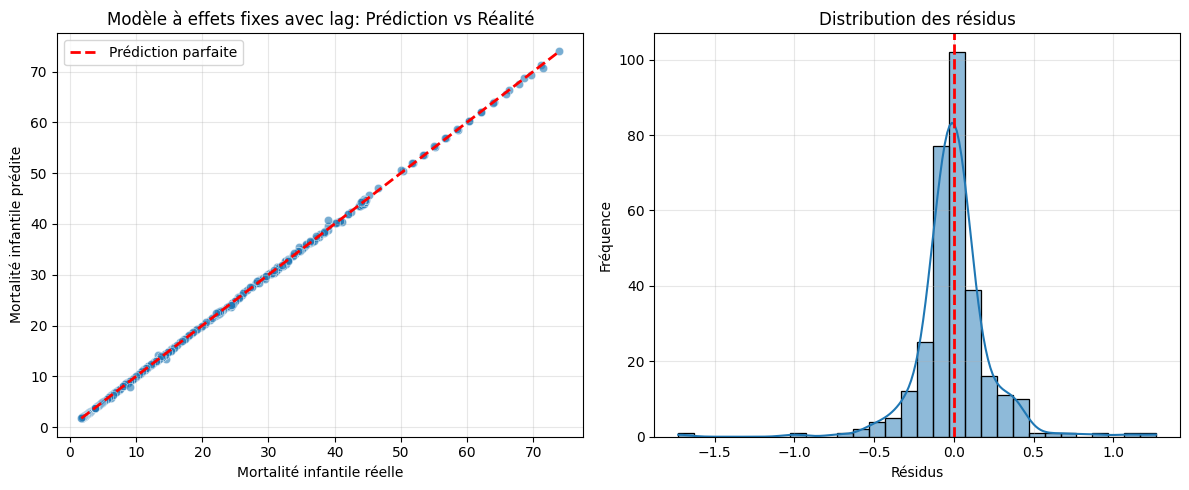

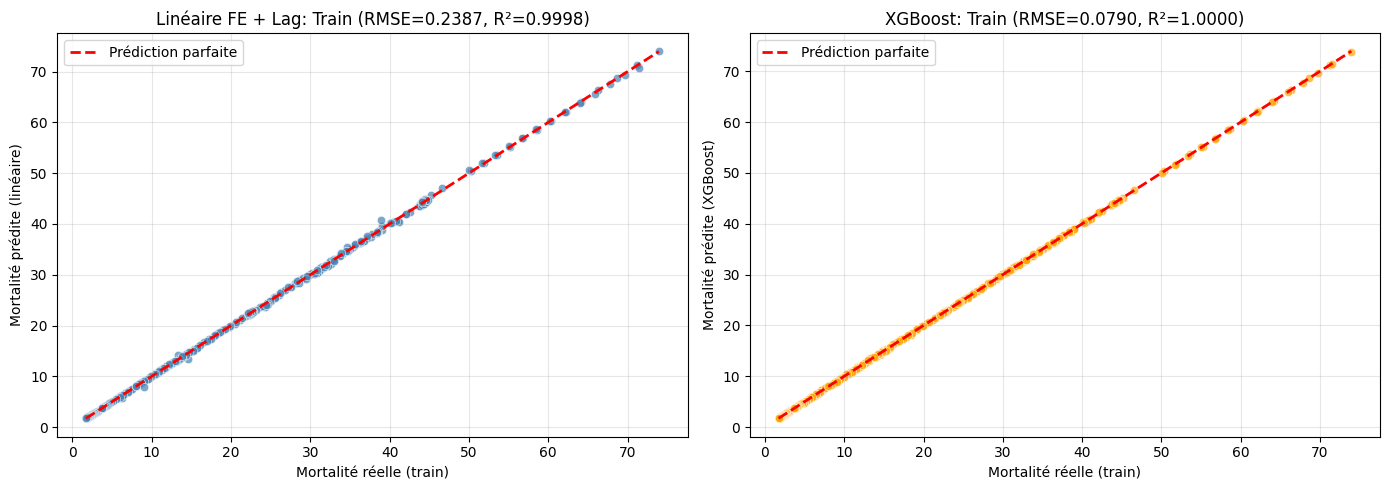

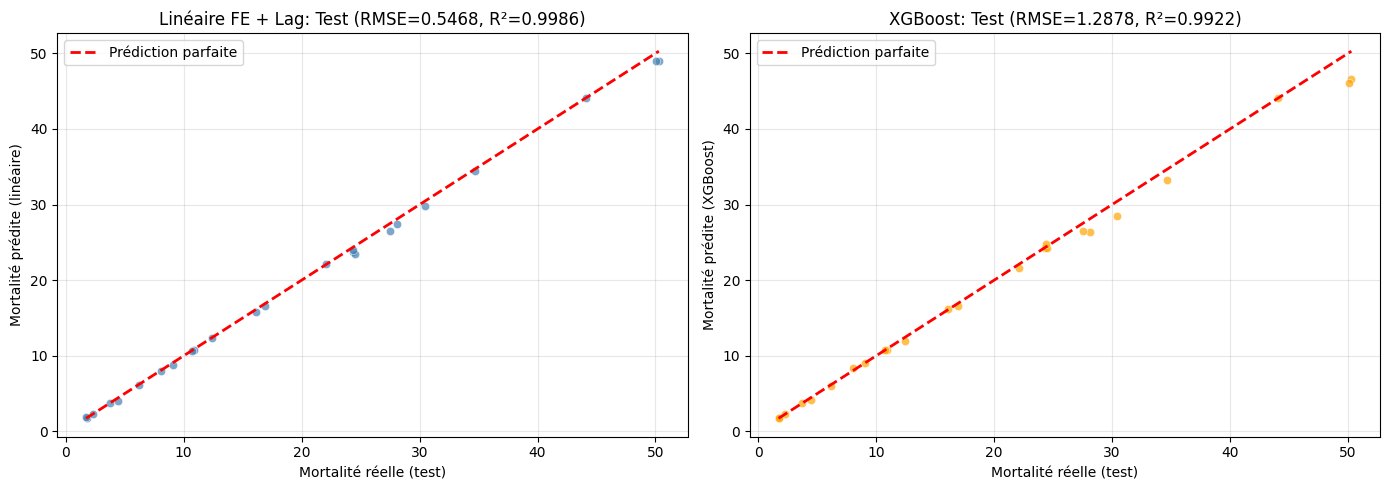

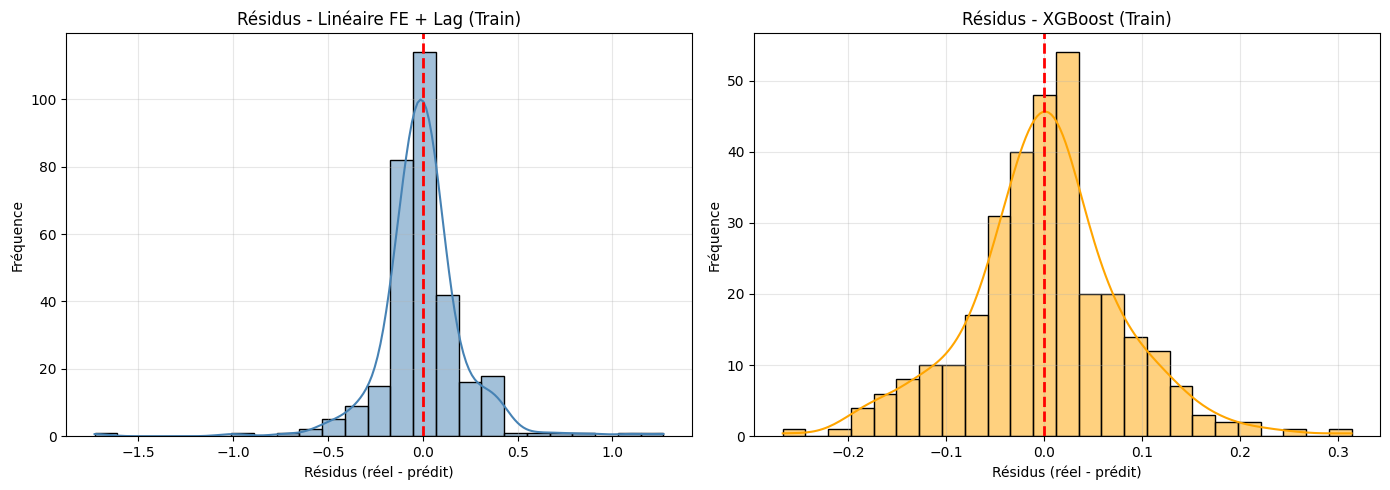

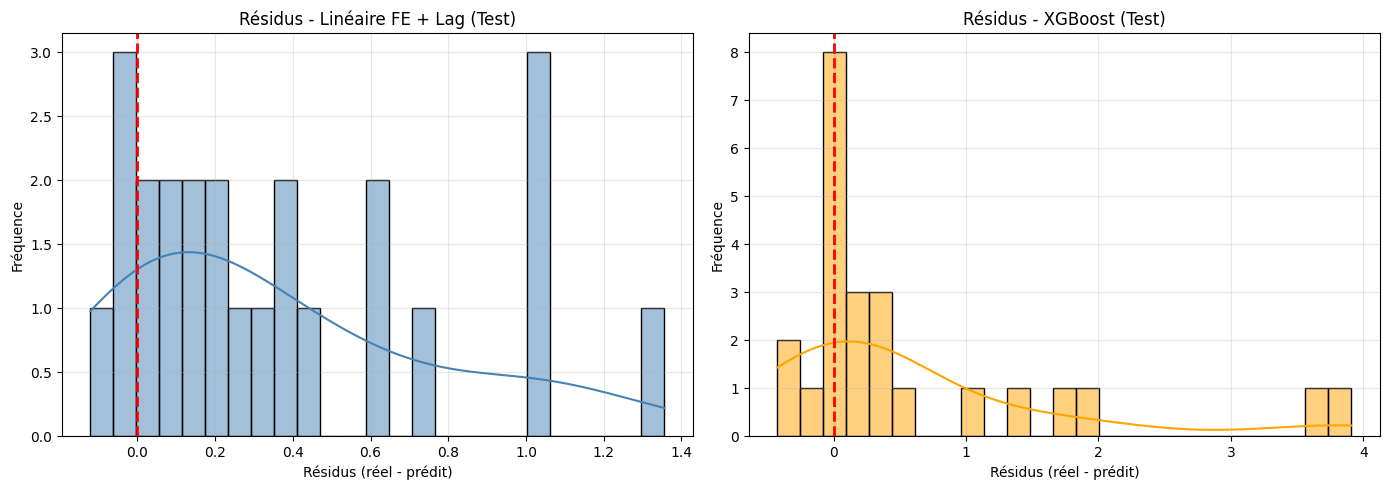

In [ ]:
def evaluate_models_walk_forward(panel_df):
    """
    Compare deux modèles sur une séparation walk-forward :
    - Régression linéaire avec lag + effets fixes par pays (réutilise la fonction de Cell 10)
    - XGBoost avec les mêmes variables d'entrée
    Retourne un dictionnaire avec les RMSE et les prédictions et sauvegarde des graphiques.
    
    Note: Réutilise panel_df (ACP déjà calculée dans Cell 4) et la fonction run_fixed_effects_regression_with_lag
    de Cell 10 pour éviter de dupliquer le code de régression. Les deux modèles sont entraînés sur les mêmes
    données d'entraînement (2010-2023) et testés sur 2024 pour une comparaison équitable.
    """
    train_mask, test_mask = walk_forward_split(panel_df, train_start_year=2010, train_end_year=2023, test_start_year=2024)
    
    # Préparation des données d'entraînement et de test
    panel_train = panel_df[train_mask].copy()
    panel_test = panel_df[test_mask].copy()
    y_train = panel_train['Target_Mortality'].values
    y_test = panel_test['Target_Mortality'].values

    # Modèle 1: Régression linéaire avec lag + effets fixes (réutilise la fonction de Cell 10)
    # On entraîne sur les données d'entraînement uniquement
    model_lin, _ = run_fixed_effects_regression_with_lag(panel_train)
    
    # Construire les features pour le test avec la même structure que l'entraînement
    # On doit construire les features manuellement pour s'assurer qu'elles correspondent
    feature_cols = ['Year', 'PC1', 'PC2', 'PC3', 'Lag_Mortality']
    X_test_num = panel_test[feature_cols].copy()
    country_dummies_test = pd.get_dummies(panel_test['Country_ID'], prefix='Country', drop_first=True)
    X_test_lin = pd.concat([X_test_num, country_dummies_test], axis=1)
    
    # Construire les features d'entraînement pour obtenir la structure attendue par le modèle
    X_train_num = panel_train[feature_cols].copy()
    country_dummies_train = pd.get_dummies(panel_train['Country_ID'], prefix='Country', drop_first=True)
    X_train_lin = pd.concat([X_train_num, country_dummies_train], axis=1)
    
    # Aligner les colonnes du test sur celles de l'entraînement
    # Ajouter les colonnes manquantes (avec des zéros) et supprimer les colonnes en trop
    for col in X_train_lin.columns:
        if col not in X_test_lin.columns:
            X_test_lin[col] = 0
    # Garder seulement les colonnes présentes dans l'entraînement, dans le même ordre
    X_test_lin = X_test_lin[X_train_lin.columns]
    
    # Prédictions sur les données d'entraînement et de test
    y_pred_lin_train = model_lin.predict(X_train_lin)
    y_pred_lin_test = model_lin.predict(X_test_lin)
    rmse_lin_train = np.sqrt(mean_squared_error(y_train, y_pred_lin_train))
    rmse_lin_test = np.sqrt(mean_squared_error(y_test, y_pred_lin_test))
    r2_lin_train = r2_score(y_train, y_pred_lin_train)
    r2_lin_test = r2_score(y_test, y_pred_lin_test)
    
    # Pour XGBoost, on utilise build_features_with_fe qui fonctionne bien
    X, y = build_features_with_fe(panel_df)
    X_train, X_test = X[train_mask], X[test_mask]

    # Modèle 2 : XGBoost 
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric='rmse'
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb_train = xgb_model.predict(X_train)
    y_pred_xgb_test = xgb_model.predict(X_test)
    rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
    rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
    r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
    r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

    print("\nÉvaluation walk-forward (Train: 2010-2023, Test: 2024)")
    print("\n=== Performance sur les données d'entraînement ===")
    print(f"Régression linéaire - RMSE: {rmse_lin_train:.4f}, R²: {r2_lin_train:.4f}")
    print(f"XGBoost            - RMSE: {rmse_xgb_train:.4f}, R²: {r2_xgb_train:.4f}")
    print("\n=== Performance sur les données de test ===")
    print(f"Régression linéaire - RMSE: {rmse_lin_test:.4f}, R²: {r2_lin_test:.4f}")
    print(f"XGBoost            - RMSE: {rmse_xgb_test:.4f}, R²: {r2_xgb_test:.4f}")

    # Visualisation - Performance sur les données d'entraînement
    # 1) Prédictions vs Valeurs Réelles pour les deux modèles (TRAIN)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_train, y=y_pred_lin_train, alpha=0.7, color='steelblue')
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité réelle (train)')
    plt.ylabel('Mortalité prédite (linéaire)')
    plt.title(f'Linéaire FE + Lag: Train (RMSE={rmse_lin_train:.4f}, R²={r2_lin_train:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_train, y=y_pred_xgb_train, alpha=0.7, color='orange')
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité réelle (train)')
    plt.ylabel('Mortalité prédite (XGBoost)')
    plt.title(f'XGBoost: Train (RMSE={rmse_xgb_train:.4f}, R²={r2_xgb_train:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('4_Modelisation/Fig20_pred_vs_actual_train.png', dpi=300, bbox_inches='tight')

    # 2) Prédictions vs Valeurs Réelles pour les deux modèles (TEST)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred_lin_test, alpha=0.7, color='steelblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité réelle (test)')
    plt.ylabel('Mortalité prédite (linéaire)')
    plt.title(f'Linéaire FE + Lag: Test (RMSE={rmse_lin_test:.4f}, R²={r2_lin_test:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred_xgb_test, alpha=0.7, color='orange')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Prédiction parfaite')
    plt.xlabel('Mortalité réelle (test)')
    plt.ylabel('Mortalité prédite (XGBoost)')
    plt.title(f'XGBoost: Test (RMSE={rmse_xgb_test:.4f}, R²={r2_xgb_test:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('4_Modelisation/Fig20_pred_vs_actual_test.png', dpi=300, bbox_inches='tight')

    # 3) Distributions des résidus des deux modèles (TRAIN)
    residuals_lin_train = y_train - y_pred_lin_train
    residuals_xgb_train = y_train - y_pred_xgb_train

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(residuals_lin_train, kde=True, bins=25, color='steelblue')
    plt.axvline(0, color='r', linestyle='--', lw=2)
    plt.xlabel('Résidus (réel - prédit)')
    plt.ylabel('Fréquence')
    plt.title('Résidus - Linéaire FE + Lag (Train)')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.histplot(residuals_xgb_train, kde=True, bins=25, color='orange')
    plt.axvline(0, color='r', linestyle='--', lw=2)
    plt.xlabel('Résidus (réel - prédit)')
    plt.ylabel('Fréquence')
    plt.title('Résidus - XGBoost (Train)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('4_Modelisation/Fig21_residuals_train.png', dpi=300, bbox_inches='tight')

    # 4) Distributions des résidus des deux modèles (TEST)
    residuals_lin_test = y_test - y_pred_lin_test
    residuals_xgb_test = y_test - y_pred_xgb_test

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(residuals_lin_test, kde=True, bins=25, color='steelblue')
    plt.axvline(0, color='r', linestyle='--', lw=2)
    plt.xlabel('Résidus (réel - prédit)')
    plt.ylabel('Fréquence')
    plt.title('Résidus - Linéaire FE + Lag (Test)')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.histplot(residuals_xgb_test, kde=True, bins=25, color='orange')
    plt.axvline(0, color='r', linestyle='--', lw=2)
    plt.xlabel('Résidus (réel - prédit)')
    plt.ylabel('Fréquence')
    plt.title('Résidus - XGBoost (Test)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('4_Modelisation/Fig21_residuals_test.png', dpi=300, bbox_inches='tight')

    return {
        'rmse_linear_fe_lag_train': rmse_lin_train,
        'rmse_linear_fe_lag_test': rmse_lin_test,
        'rmse_xgboost_train': rmse_xgb_train,
        'rmse_xgboost_test': rmse_xgb_test,
        'r2_linear_fe_lag_train': r2_lin_train,
        'r2_linear_fe_lag_test': r2_lin_test,
        'r2_xgboost_train': r2_xgb_train,
        'r2_xgboost_test': r2_xgb_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred_lin_train': y_pred_lin_train,
        'y_pred_lin_test': y_pred_lin_test,
        'y_pred_xgb_train': y_pred_xgb_train,
        'y_pred_xgb_test': y_pred_xgb_test,
    }


# Évaluation des modèles sur la séparation walk-forward (2010-2023 entrainement, 2024 test)
# Utilise le panel_df déjà calculé (ACP déjà faite dans Cell 4) et réutilise la fonction 
# run_fixed_effects_regression_with_lag de Cell 10 pour éviter de dupliquer le code
evaluate_models_walk_forward(panel_df)

Nous constatons que le modèle XGBoost présente une dispersion légèrement plus marquée que le modèle de regréssion linéaire à effets fixes (modèle B), notamment pour les valeurs de mortalité infantile les plus élevées où il a tendance à sous-estimer légèrement la réalité. 

D'autre part dans le modèle linéaire, les résidus sont proches de zéro et assez réguliers, avec seulement quelques valeurs un peu plus grandes, ce qui montre que le modèle se trompe rarement mais peut sous-estimer certains points. 
Pour XGBoost, les résidus sont plus dispersés et certains sont beaucoup plus grands, ce qui indique que le modèle fait quelques grosses erreurs, même s’il capture mieux la complexité des données.

Finalement le modèle linéaire semble produire des résidus plus concentrés et plus symétriques, tandis que XGBoost capture mieux la complexité des données mais au prix de quelques erreurs plus importantes. 

Dans les deux modèles, les résidus ont tendance à être positif, c'est à dire que la valeur réelle est souvent plus faible que la valeur prédite. Cela peut être du à la tendance baissière du taux de mortalité avec le temps due au progès par exemple. 

Les erreurs de prédiction des valeurs de mortalité infantile les plus élevées peuvent être dues à la structure du jeu de données. En effet, les valeurs de mortalité infantile très élevée sont rares dans le jeu de données, donc le modèle dispose de peu d'exemples sur lesquels s'entrainer. Pour ces valeurs il peut donc avoir tendance à se recentrer vers la moyenne, sous estimant les valeurs extrêmes. 
